In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("covid_global.csv")
print("import is successfull")

import is successfull


In [6]:
df.head(10)

,Country,Continent,Date,Cases,Deaths,Vaccinations
0,India,Asia,2020-01-01,30314,824,0
1,India,Asia,2020-02-01,71413,1710,0
2,India,Asia,2020-03-01,120849,2426,0
3,India,Asia,2020-04-01,183151,4037,0
4,India,Asia,2020-05-01,273291,6139,0
5,India,Asia,2020-06-01,359880,8521,0
6,India,Asia,2020-07-01,482966,10416,0
7,India,Asia,2020-08-01,590771,12026,0
8,India,Asia,2020-09-01,706035,14376,0
9,India,Asia,2020-10-01,825097,16359,0


In [7]:
df.shape

(480, 6)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       480 non-null    object
 1   Continent     480 non-null    object
 2   Date          480 non-null    object
 3   Cases         480 non-null    int64 
 4   Deaths        480 non-null    int64 
 5   Vaccinations  480 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 22.6+ KB


In [9]:
df.describe()

,Cases,Deaths,Vaccinations
count,4.800000e+02,480.000000,4.800000e+02
mean,5.388148e+05,10879.118750,8.697768e+05
std,4.870903e+05,9624.429554,1.607570e+06
min,3.227000e+03,72.000000,0.000000e+00
25%,1.649628e+05,3356.750000,0.000000e+00
50%,4.299515e+05,8806.000000,5.958500e+03
75%,7.762402e+05,15823.500000,1.123661e+06
max,2.778084e+06,56121.000000,1.239569e+07


In [10]:
df.isnull().count()

Country         480
Continent       480
Date            480
Cases           480
Deaths          480
Vaccinations    480
dtype: int64

In [11]:
df.duplicated().count()

np.int64(480)

In [12]:
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
df.dtypes

Country                 object
Continent               object
Date            datetime64[ns]
Cases                    int64
Deaths                   int64
Vaccinations             int64
dtype: object

In [14]:
df.head(10)

,Country,Continent,Date,Cases,Deaths,Vaccinations
0,India,Asia,2020-01-01,30314,824,0
1,India,Asia,2020-02-01,71413,1710,0
2,India,Asia,2020-03-01,120849,2426,0
3,India,Asia,2020-04-01,183151,4037,0
4,India,Asia,2020-05-01,273291,6139,0
5,India,Asia,2020-06-01,359880,8521,0
6,India,Asia,2020-07-01,482966,10416,0
7,India,Asia,2020-08-01,590771,12026,0
8,India,Asia,2020-09-01,706035,14376,0
9,India,Asia,2020-10-01,825097,16359,0


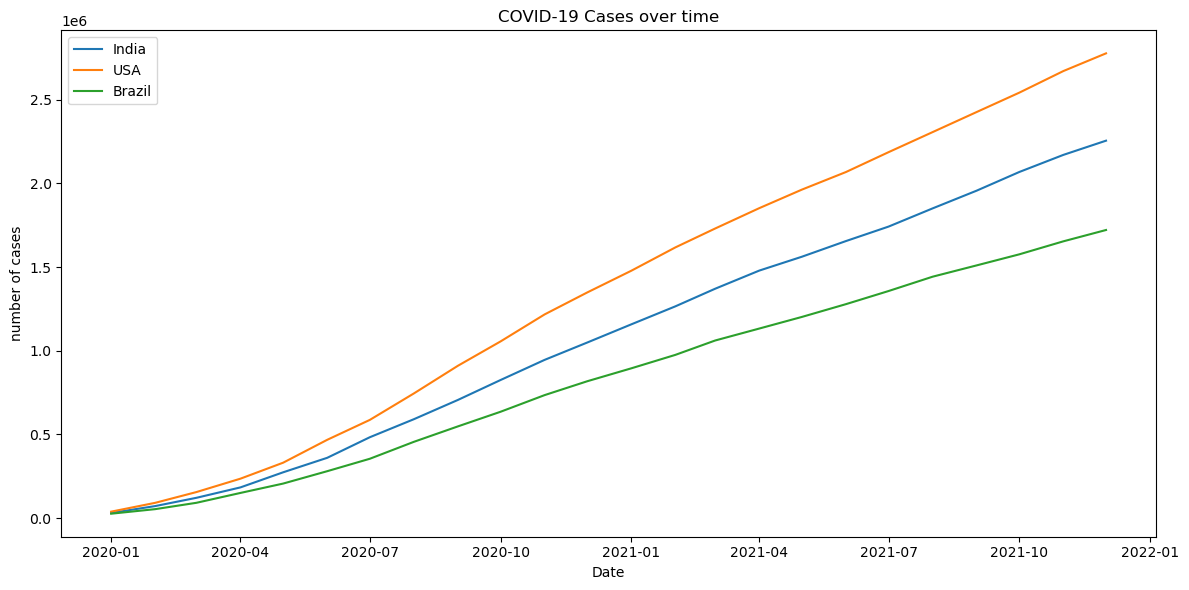

In [15]:
plt.figure(figsize=(12,6))
# filter the country
for country in ["India","USA","Brazil"]:
    country_data = df[df["Country"]==country]
    plt.plot(country_data["Date"],country_data["Cases"],label=country)

#add tittle and labels
plt.title("COVID-19 Cases over time")
plt.xlabel("Date")
plt.ylabel("number of cases")
plt.legend()
plt.tight_layout()
plt.savefig("cases_trend.png")
plt.show()

C:\Users\krupa\AppData\Local\Temp\ipykernel_13428\3910260091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


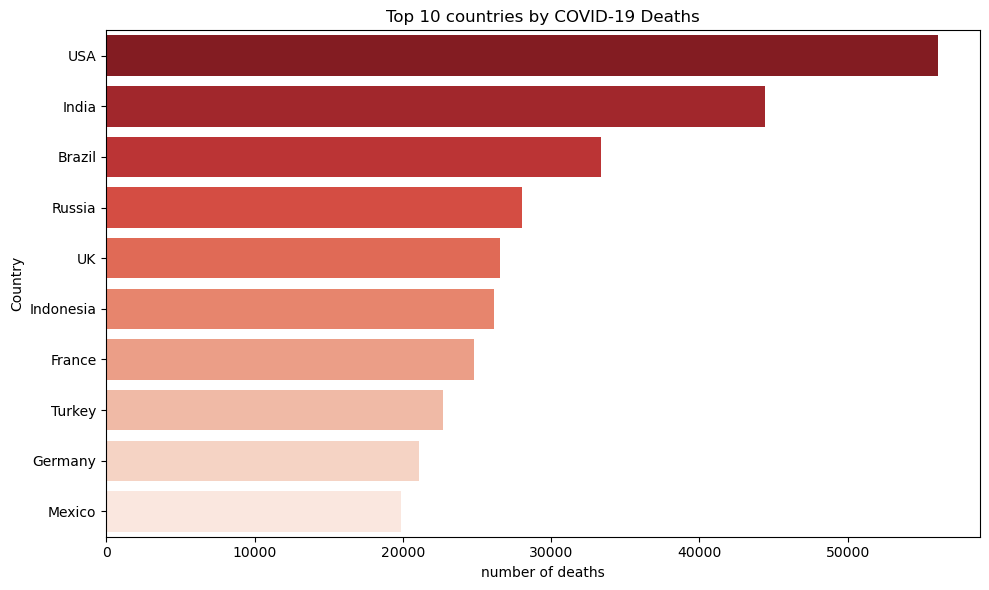

In [17]:
top_deaths = df.groupby("Country")["Deaths"].max().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_deaths.values,
    y=top_deaths.index,
    palette="Reds_r"
)
plt.title("Top 10 countries by COVID-19 Deaths")
plt.xlabel("number of deaths")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_10_deaths.png")
plt.show()

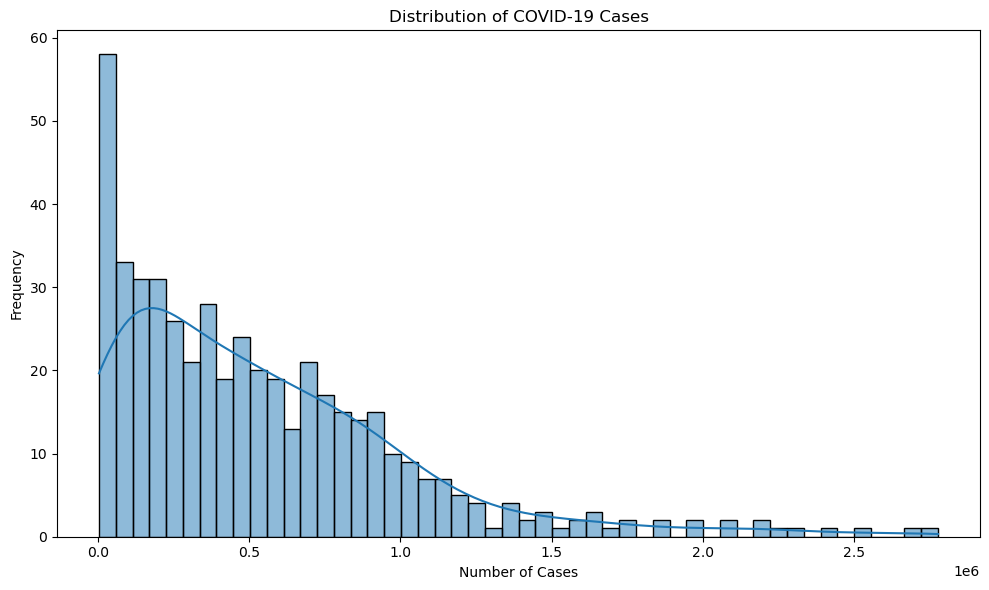

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df["Cases"], bins=50,kde=True)
plt.title("Distribution of COVID-19 Cases")
plt.xlabel("Number of Cases")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("cases_histogram.png")
plt.show()

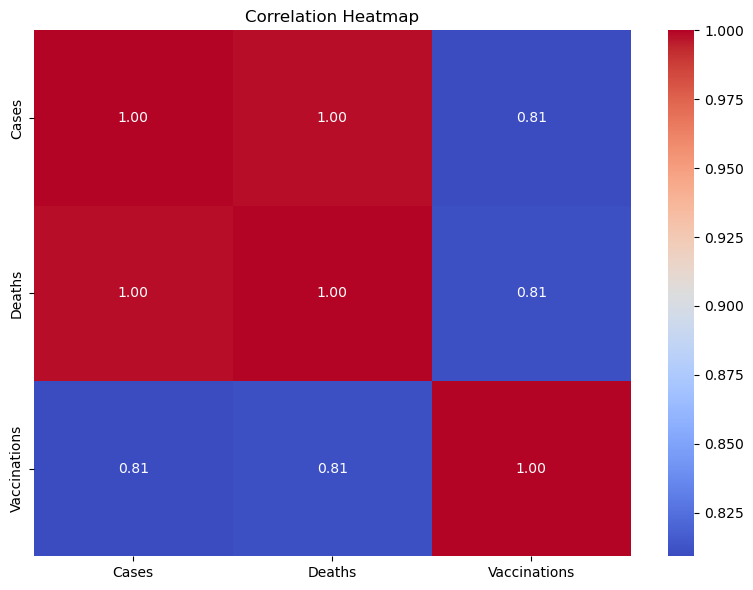

In [20]:
numeric_df = df[["Cases", "Deaths", "Vaccinations"]]
corr = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

C:\Users\krupa\AppData\Local\Temp\ipykernel_13428\4127173398.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


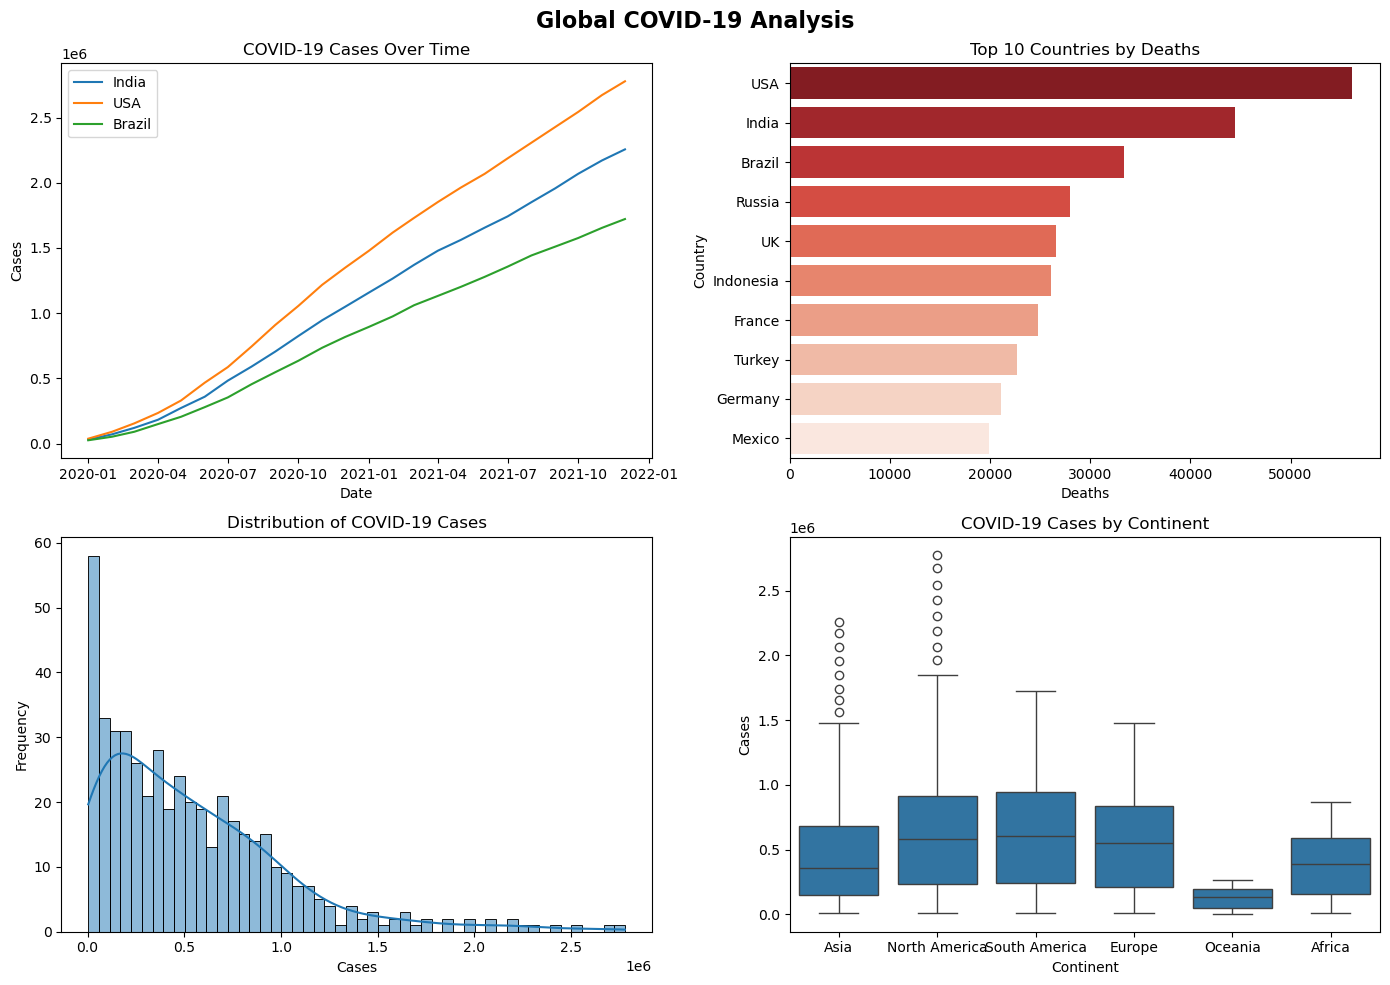

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Chart 1: Cases over time
for country in ["India", "USA", "Brazil"]:
    country_data = df[df["Country"] == country]
    axes[0, 0].plot(
        country_data["Date"],
        country_data["Cases"],
        label=country
    )

axes[0, 0].set_title("COVID-19 Cases Over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Cases")
axes[0, 0].legend()
# Chart 2: Top 10 deaths
top_deaths = df.groupby("Country")["Deaths"].max().nlargest(10)

sns.barplot(
    x=top_deaths.values,
    y=top_deaths.index,
    ax=axes[0, 1],
    palette="Reds_r"
)

axes[0, 1].set_title("Top 10 Countries by Deaths")
axes[0, 1].set_xlabel("Deaths")
axes[0, 1].set_ylabel("Country")
# Chart 3: Cases distribution

sns.histplot(
    df["Cases"],
    bins=50,
    kde=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribution of COVID-19 Cases")
axes[1, 0].set_xlabel("Cases")
axes[1, 0].set_ylabel("Frequency")
# Chart 4: Cases by continent

sns.boxplot(
    x="Continent",
    y="Cases",
    data=df,
    ax=axes[1, 1]
)

axes[1, 1].set_title("COVID-19 Cases by Continent")
axes[1, 1].set_xlabel("Continent")
axes[1, 1].set_ylabel("Cases")
# Main dashboard title
fig.suptitle(
    "Global COVID-19 Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
# Save dashboard
plt.savefig(
    "covid_dashboard.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()